# CloudWatch-Style Intrusion Detection Assignment\n

Paired with `src/train.py` for a full pipeline run.

## Part 1 - Defining the Problem
The goal of this project is to detect malicious or suspicious network behavior from log data.

- **Attacker behavior to detect:** suspicious/malicious network interactions (scanning, probing, brute-force, suspicious request patterns).
- **False positive cost:** analyst fatigue, wasted triage time, possible blocking of legitimate users.
- **False negative cost:** missed intrusion, potential data loss and persistence.
- **Why NN may help (or not):** NNs can capture nonlinear interactions; tree/linear baselines can still be strong for tabular data.

In [23]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / 'src').exists() and (ROOT.parent / 'src').exists():
    ROOT = ROOT.parent
sys.path.append(str(ROOT))

from src.train import (
    load_csv_robust,
    infer_target_column,
    build_binary_target,
    build_preprocessor,
    densify_if_needed,
    build_nn,
    train_torch_nn,
    predict_torch_probs,
    compute_metrics,
    export_failure_cases,
)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

RANDOM_STATE = 42

In [24]:
# Set dataset and target mapping
DATA_PATH = ROOT / 'data' / 'dionaeaClean2.csv'
TARGET_COLUMN = 'protocol'
POSITIVE_LABELS = {
    'mssqld', 'httpd', 'mysqld', 'pptpd', 'ftpd', 'mongod', 'epmapper', 'mqttd'
}
MAX_CAT_CARDINALITY = 100

df = load_csv_robust(DATA_PATH)
df.columns = [str(c).strip() for c in df.columns]
df = df.drop_duplicates().reset_index(drop=True)

target_col = infer_target_column(df, TARGET_COLUMN)
y, target_mapping_note = build_binary_target(df[target_col], POSITIVE_LABELS)
class_counts = y.value_counts().sort_index()
if class_counts.size < 2:
    raise ValueError(
        f'Single-class target after mapping: {class_counts.to_dict()}. '
        'Choose a dataset/target mapping with both benign and malicious labels.'
    )

X = df.drop(columns=[target_col]).copy()
constant_cols = [c for c in X.columns if X[c].nunique(dropna=False) <= 1]
if constant_cols:
    X = X.drop(columns=constant_cols)

print(f'Target column: {target_col}')
print(f'Target mapping: {target_mapping_note}')
print('Class distribution (counts):')
print(class_counts)
print('Class distribution (proportion):')
print(y.value_counts(normalize=True).sort_index())

Target column: protocol
Target mapping: Used user-supplied positive labels: ['epmapper', 'ftpd', 'httpd', 'mongod', 'mqttd', 'mssqld', 'mysqld', 'pptpd'].
Class distribution (counts):
protocol
0    27433
1      141
Name: count, dtype: int64
Class distribution (proportion):
protocol
0    0.994886
1    0.005114
Name: proportion, dtype: float64


## Part 2 - Data Preparation & Feature Engineering\n
\n
This section performs split, missing-value handling, categorical encoding, and numeric normalization.

In [25]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.1765, stratify=y_trainval, random_state=RANDOM_STATE
)

preprocessor, numeric_cols, categorical_cols, dropped_high_card = build_preprocessor(
    X_train, MAX_CAT_CARDINALITY
)

X_train_t = densify_if_needed(preprocessor.fit_transform(X_train))
X_val_t = densify_if_needed(preprocessor.transform(X_val))
X_test_t = densify_if_needed(preprocessor.transform(X_test))

print(f'Train shape after preprocessing: {X_train_t.shape}')
print(f'Numeric columns: {len(numeric_cols)}')
print(f'Categorical columns (encoded): {len(categorical_cols)}')
print(f'High-cardinality categorical columns dropped: {dropped_high_card}')

Train shape after preprocessing: (19300, 92)
Numeric columns: 0
Categorical columns (encoded): 2
High-cardinality categorical columns dropped: ['src_port', 'timestamp']


## Part 3 - Neural Network Classifier

Architecture constraints satisfied:
- Fully connected feedforward
- 3 hidden layers
- ReLU hidden activations
- Sigmoid output

In [26]:
import torch
from sklearn.utils.class_weight import compute_class_weight

torch.manual_seed(RANDOM_STATE)

y_train_int = np.asarray(y_train, dtype=np.int64)
present_classes = np.unique(y_train_int)
if len(present_classes) < 2:
    raise ValueError(
        f'Training split has one class only: {present_classes}. '
        'Use a dataset/target mapping with both benign (0) and malicious (1).'
    )

cw = compute_class_weight(
    class_weight='balanced',
    classes=present_classes,
    y=y_train_int,
)
class_weight = {0: 1.0, 1: 1.0}
for cls, w in zip(present_classes, cw):
    class_weight[int(cls)] = float(w)

nn_model = build_nn(X_train_t.shape[1])
history = train_torch_nn(
    model=nn_model,
    X_train=np.asarray(X_train_t, dtype=np.float32),
    y_train=np.asarray(y_train, dtype=np.float32),
    X_val=np.asarray(X_val_t, dtype=np.float32),
    y_val=np.asarray(y_val, dtype=np.float32),
    class_weights=class_weight,
    epochs=40,
    batch_size=256,
    patience=5,
)

Epoch 01/40 - loss: 0.4877 - acc: 0.9982 - val_loss: 0.0207 - val_acc: 1.0000
Epoch 02/40 - loss: 0.0144 - acc: 1.0000 - val_loss: 0.0011 - val_acc: 1.0000
Epoch 03/40 - loss: 0.0011 - acc: 1.0000 - val_loss: 0.0003 - val_acc: 1.0000
Epoch 04/40 - loss: 0.0005 - acc: 1.0000 - val_loss: 0.0002 - val_acc: 1.0000
Epoch 05/40 - loss: 0.0003 - acc: 1.0000 - val_loss: 0.0001 - val_acc: 1.0000
Epoch 06/40 - loss: 0.0002 - acc: 1.0000 - val_loss: 0.0001 - val_acc: 1.0000
Epoch 07/40 - loss: 0.0001 - acc: 1.0000 - val_loss: 0.0000 - val_acc: 1.0000
Epoch 08/40 - loss: 0.0001 - acc: 1.0000 - val_loss: 0.0000 - val_acc: 1.0000
Epoch 09/40 - loss: 0.0001 - acc: 1.0000 - val_loss: 0.0000 - val_acc: 1.0000
Epoch 10/40 - loss: 0.0001 - acc: 1.0000 - val_loss: 0.0000 - val_acc: 1.0000
Epoch 11/40 - loss: 0.0000 - acc: 1.0000 - val_loss: 0.0000 - val_acc: 1.0000
Epoch 12/40 - loss: 0.0000 - acc: 1.0000 - val_loss: 0.0000 - val_acc: 1.0000
Epoch 13/40 - loss: 0.0000 - acc: 1.0000 - val_loss: 0.0000 - va

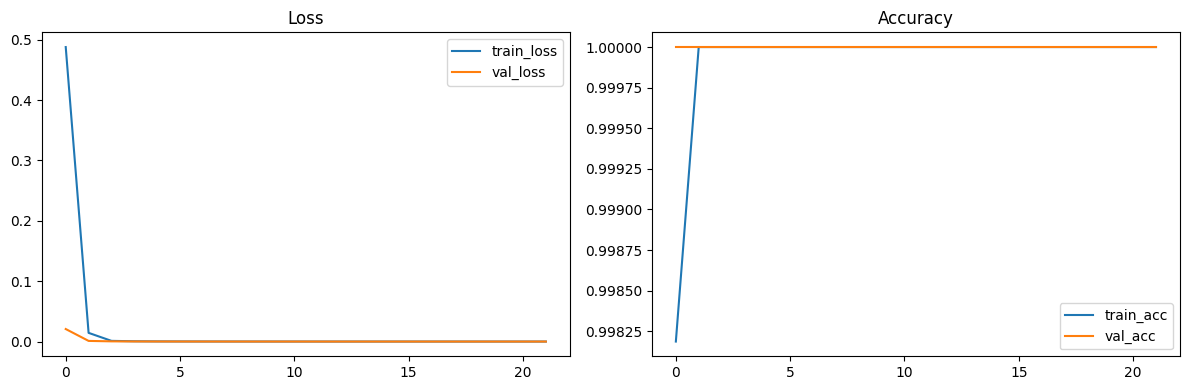

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['loss'], label='train_loss')
axes[0].plot(history['val_loss'], label='val_loss')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history['accuracy'], label='train_acc')
axes[1].plot(history['val_accuracy'], label='val_acc')
axes[1].set_title('Accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()

In [28]:
nn_probs = predict_torch_probs(nn_model, np.asarray(X_test_t, dtype=np.float32))
nn_preds = (nn_probs >= 0.5).astype(int)
nn_metrics = compute_metrics(np.asarray(y_test), nn_preds)
nn_metrics

{'accuracy': 1.0,
 'precision': 1.0,
 'recall': 1.0,
 'f1': 1.0,
 'false_positives': 0,
 'false_negatives': 0,
 'true_positives': 21,
 'true_negatives': 4116}

## Part 4 - Baseline Comparison

Train a non-NN model and compare Accuracy, Precision, Recall, F1, and FP/FN.

In [29]:
baseline = LogisticRegression(max_iter=3000, class_weight='balanced')
baseline.fit(X_train_t, np.asarray(y_train))

base_probs = baseline.predict_proba(X_test_t)[:, 1]
base_preds = (base_probs >= 0.5).astype(int)
base_metrics = compute_metrics(np.asarray(y_test), base_preds)

comparison = pd.DataFrame([
    {'model': 'NeuralNetwork', **nn_metrics},
    {'model': 'LogisticRegression', **base_metrics},
])
comparison

,model,accuracy,precision,recall,f1,false_positives,false_negatives,true_positives,true_negatives
0,NeuralNetwork,1.0,1.0,1.0,1.0,0,0,21,4116
1,LogisticRegression,1.0,1.0,1.0,1.0,0,0,21,4116


## Part 5 - Failure Case Analysis

This exports up to 5 NN misclassified examples with a starter failure-type tag.

In [30]:
fail_path = ROOT / 'outputs' / 'failure_cases_notebook.csv'
fail_path.parent.mkdir(parents=True, exist_ok=True)
mis_total = export_failure_cases(
    X_test_raw=X_test,
    y_true=np.asarray(y_test),
    y_pred=nn_preds,
    y_prob=nn_probs,
    output_csv=fail_path,
    max_rows=5,
)
print(f'Total NN misclassifications: {mis_total}')
pd.read_csv(fail_path).head(5)

Total NN misclassifications: 0


,note


## Part 6 - Analysis
- Should this model operate autonomously?
- How should analysts interact with it?
- Ethical risks of false accusations?
- How could bias manifest?

## Optional: One-command run

You can also run everything from script mode:

```bash
python src/train.py --data data/CloudWatch_Traffic_Web_Attack.csv --target protocol --positive-labels mssqld,httpd,mysqld,pptpd,ftpd,mongod,epmapper,mqttd
```

Artifacts are saved to `outputs/`.